$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.12

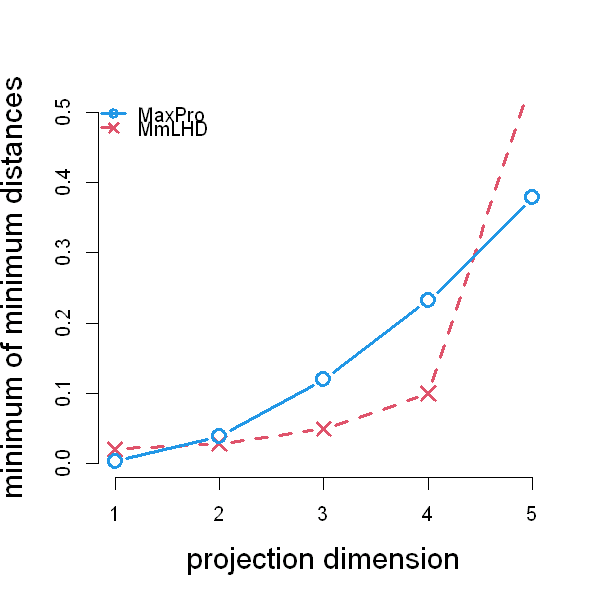

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

图 4.12 对比了最大投影设计与极大极小拉丁超立方设计:分别绘制二者在 1 维,2 维,3 维,4 维子空间投影以及完整高维空间内,采样点间最小距离的下界.可见在完整高维空间中,极大极小拉丁超立方设计拥有更大的最小距离,这一点符合预期,因为该设计正是以最大化全空间最小距离为目标构造得到.但当采样点投影至 2 维,3 维或 4 维子空间时,最大投影设计具备更大的最小距离.该特性十分关键,因为开展试验前无法预知有多少变量是重要变量.最大投影设计在一维投影上的最小距离小于极大极小拉丁超立方设计,原因在于最大投影设计有更多采样点靠近区域边界.总体而言,最大投影设计通常在 $2,\dots,p-1$ 维投影上表现优于极大极小拉丁超立方设计,因此能够更好地应对变量重要性未知带来的不确定性.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽 5 英寸,高 5 英寸.设置种子为 `2`.使用 `SFDesign` 包中的 `maxproLHD` 函数生成一个随机的 `2` 维 `7` 点拉丁超立方设计,取出其中的 `design` 列,令其为 `D2`.使用 `SFDesign` 包中的 `maxpro.optim` 函数执行完整的 MaxPro 优化流程,取出其中的 `design` 列作为最终的设计点,令其为 `D2`.

```r
options(repr.plot.width=5,repr.plot.height=5)
p=5;n=50
set.seed(2)
library(SFDesign)
D1=maximinLHD(n,p)$design
set.seed(2)
D2=maxpro.optim(maxproLHD(n,p)$design)$design
```

创建函数 `min_mindist`,输入为一个设计矩阵 `M`,输出为一个长度为 `p` 的向量,其中第 `j` 个元素为该设计在所有 $j$ 维子空间投影下的最小距离的下界.将矩阵第一列命名为 `n`,第二列命名为 `p`.初始化最终输出向量 `a` 为长度为 `p` 的零向量.对于每个维度 `j`,使用 `gtools` 包中的 `combinations` 函数生成所有可能的列组合,令其为 `comb`.令其行数为 `k`.初始化一个长度为 `k` 的零向量 `temp`.对于每个组合 `i`,计算该组合对应的子矩阵的最小距离,并将其存入 `temp[i]`.将 `temp` 中的最小值赋给 `a[j]`.最后返回向量 `a`.

```r
min_mindist=function(M)
{
  n=dim(M)[1]
  p=dim(M)[2]
  a=rep(0,p)
  for(j in 1:p)
  {
    library(gtools)
    comb=combinations(p,j)
    k=dim(comb)[1]
    temp=rep(0,k)
    for(i in 1:k)
    {
      temp[i]=min(dist(M[,comb[i,]]))
    }
    a[j]=min(temp)
  }
  return(a)
}
```

对 `D1` 和 `D2` 分别调用 `min_mindist` 函数,得到两个向量 `d1` 和 `d2`.将 `d1` 和 `d2` 绘制在同一张图上,其中类型为同时画点和线,点的形状分别为叉和空心圆,颜色分别为红色和蓝色,线型分别为虚线和直线,不显示边框,$x$ 轴范围为 `1` 到 `5`,$y$ 轴范围为 `0` 到 `0.5`,$x$ 轴标签为 `projection dimension`,y 轴标签为 `minimum of minimum distances`,点的大小为 `1.5`,标签的大小为 `1.5`,线宽为 `3`.添加图例,分别标注 "MaxPro" 和 "MmLHD",点的形状,线型,线宽和颜色与图中一致,不显示边框.

```r
d1=min_mindist(D1)
d2=min_mindist(D2)
matplot(1:p,cbind(d1,d2),type="b",pch=c(4,1),col=c(2,4),lty=c(2,1),bty="n",xlim=c(1,5),ylim=c(0,0.5),xlab="projection dimension",ylab="minimum of minimum distances",cex=1.5,cex.lab=1.5,lwd=3)
legend("topleft",c("MaxPro","MmLHD"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

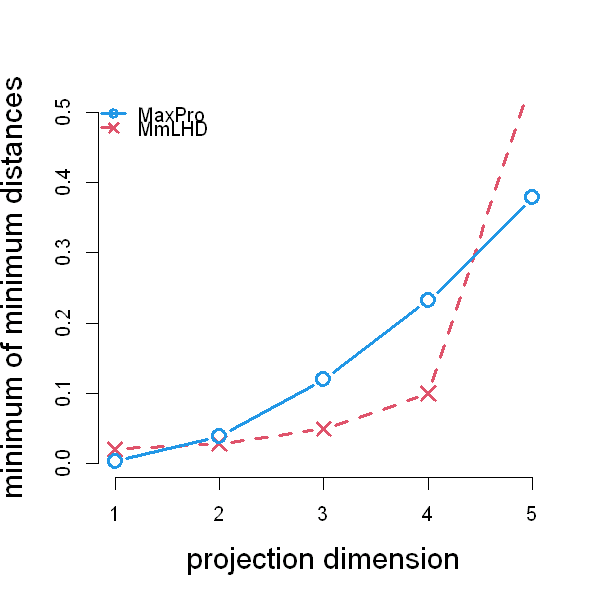

In [2]:
# 图 4.12

options(repr.plot.width=5,repr.plot.height=5)
p=5;n=50
set.seed(2)
library(SFDesign)
D1=maximinLHD(n,p)$design
set.seed(2)
D2=maxpro.optim(maxproLHD(n,p)$design)$design

min_mindist=function(M)
{
  n=dim(M)[1]
  p=dim(M)[2]
  a=rep(0,p)
  for(j in 1:p)
  {
    library(gtools)
    comb=combinations(p,j)
    k=dim(comb)[1]
    temp=rep(0,k)
    for(i in 1:k)
    {
      temp[i]=min(dist(M[,comb[i,]]))
    }
    a[j]=min(temp)
  }
  return(a)
}

d1=min_mindist(D1)
d2=min_mindist(D2)
matplot(1:p,cbind(d1,d2),type="b",pch=c(4,1),col=c(2,4),lty=c(2,1),bty="n",xlim=c(1,5),ylim=c(0,0.5),xlab="projection dimension",ylab="minimum of minimum distances",cex=1.5,cex.lab=1.5,lwd=3)
legend("topleft",c("MaxPro","MmLHD"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$